In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# ==========================
# Load Dataset


df = pd.read_csv("loan_data.csv")
print(df.head())

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0           561  

In [ ]:

# Check Dataset


print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:

# Handle Missing Values


df = df.dropna()


In [ ]:

# Encode Categorical Columns


le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [9]:
print(df.columns.tolist())

['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']


In [ ]:

# Select Features and Target


# Replace 'Loan_Status' with your target column
X = df.drop("loan_status", axis=1)
y = df["loan_status"]


In [ ]:

# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:

# Train Logistic Regression


model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


C:\Users\WELCOME\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:

# Prediction

y_pred = model.predict(X_test)

# Evaluation Metrics

In [14]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)


Confusion Matrix
[[6488  502]
 [ 576 1434]]


In [16]:
precision = precision_score(y_test, y_pred)
print("\nPrecision :", precision)


Precision : 0.7407024793388429


In [17]:
recall = recall_score(y_test, y_pred)
print("Recall :", recall)

Recall : 0.7134328358208956


In [18]:
f1 = f1_score(y_test, y_pred)
print("F1 Score :", f1)

F1 Score : 0.7268119614799797


In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)


Accuracy : 0.8802222222222222


In [20]:
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      6990
           1       0.74      0.71      0.73      2010

    accuracy                           0.88      9000
   macro avg       0.83      0.82      0.83      9000
weighted avg       0.88      0.88      0.88      9000



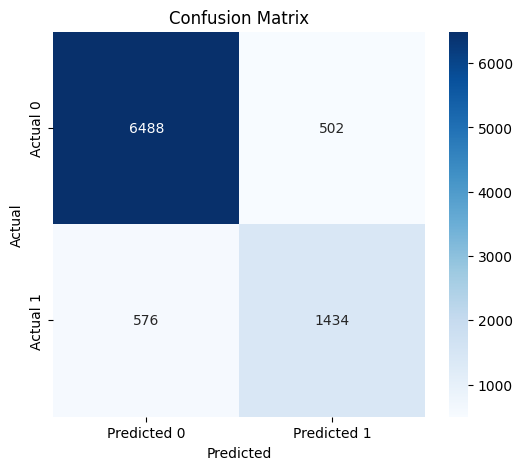

In [ ]:
# Plot Confusion Matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0','Predicted 1'],
    yticklabels=['Actual 0','Actual 1']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

1. Confusion Matrix

Conclusion:

The confusion matrix shows that the model correctly classified 6,488 negative instances and 1,434 positive instances, while incorrectly classifying 502 negative instances as positive and 576 positive instances as negative. Since the number of correct predictions is much higher than the number of incorrect predictions, the model demonstrates good overall classification performance.

2. Precision (74.07%)

Conclusion:

The model achieved a Precision of 74.07%, which means that 74.07% of the instances predicted as positive were actually positive. This indicates that the model is reasonably reliable in making positive predictions, although some false positive predictions are still present.

3. Recall (71.34%)

Conclusion:

The model achieved a Recall of 71.34%, indicating that it correctly identified 71.34% of all actual positive instances. This suggests that the model is able to detect most positive cases but still misses approximately 28.66% of them, resulting in some false negatives.

4. F1-Score (72.68%)

Conclusion:

The model obtained an F1-Score of 72.68%, which reflects a good balance between precision and recall. This indicates that the model provides consistent classification performance by maintaining a reasonable trade-off between minimizing false positives and false negatives.

5. Accuracy (88.02%)

Conclusion:

The model achieved an Accuracy of 88.02%, meaning it correctly classified 88.02% of the total instances in the dataset. This high accuracy demonstrates strong overall predictive performance. However, it should be interpreted together with precision, recall, and F1-score to obtain a comprehensive evaluation of the model.